**Cloning the YOLOv5 repository and installing the required dependencies**

In [ ]:
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
!pip install -qr requirements.txt

Cloning into 'yolov5'...
remote: Enumerating objects: 17851, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 17851 (delta 28), reused 9 (delta 7), pack-reused 17809 (from 3)
Receiving objects: 100% (17851/17851), 16.98 MiB | 19.53 MiB/s, done.
Resolving deltas: 100% (12164/12164), done.
/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 11.9 MB/s eta 0:00:00


**Defining the path to the input image used for object detection**

In [ ]:
IMAGE_PATH = "/content/test_image.jpg"

**Running the YOLOv5 detection on the input image and saving the results**

In [ ]:
!python detect.py --weights yolov5s.pt --img 640 --conf 0.25 --source "/content/test_image.jpg" --save-txt --save-conf

detect: weights=['yolov5s.pt'], source=/content/test_image.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_format=0, save_csv=False, save_conf=True, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-463-g88af13e3 Python-3.12.13 torch-2.10.0+cpu CPU

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
image 1/1 /content/test_image.jpg: 448x640 22 persons, 2 bicycles, 9 cars, 1 traffic light, 2 backpacks, 306.7ms
Speed: 2.7ms pre-process, 306.7ms inference, 41.9ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detect/exp2
1 labels saved to runs/detect/exp2/labels


**Loading and displaying the detected output image from the results folder**

Result image: /content/yolov5/runs/detect/exp2/test_image.jpg


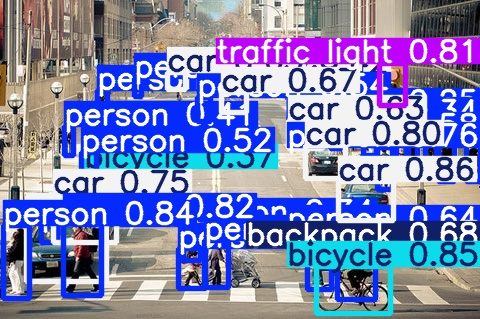

In [ ]:
import glob
from IPython.display import Image, display

result_images = sorted(glob.glob("/content/yolov5/runs/detect/exp*/test_image.jpg"))
print("Result image:", result_images[-1])

display(Image(filename=result_images[-1]))

**Loading th YOLOv5 model using PyTorch Hub and perform inference with timing**

/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /root/.cache/torch/hub/master.zip


YOLOv5 🚀 2026-3-23 Python-3.12.13 torch-2.10.0+cpu CPU

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
image 1/1: 319x480 22 persons, 2 bicycles, 9 cars, 1 traffic light, 2 backpacks
Speed: 18.2ms pre-process, 519.4ms inference, 7.5ms NMS per image at shape (1, 3, 448, 640)


Inference time: 546.87 ms


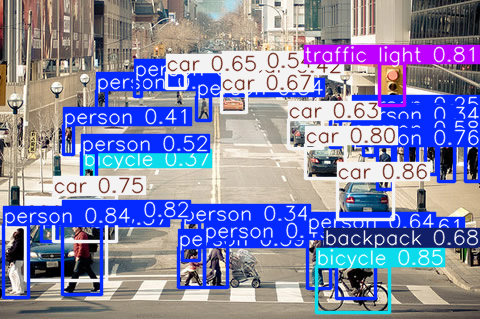

In [ ]:
import torch
import time
from PIL import Image

model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)
model.conf = 0.25

img = Image.open(IMAGE_PATH).convert("RGB")

start = time.time()
results = model(img)
end = time.time()

print(f"Inference time: {(end - start)*1000:.2f} ms")
results.print()
results.show()